# PEC3-Tipología y fuentes de datos
**Nombre:**Gabriel Costa Riesco  
**Asignatura:**Tipología y fuentes de datos  
**Fecha:**05/05/2026


## Uso responsable de la inteligencia artificial

En la UOC reconocemos el valor formativo de la inteligencia artificial (IA), pero también sus riesgos si no se emplea con ética, criterio y transparencia:  https://www.uoc.edu/es/news/2024/posicionamento-de-la-uoc-sobre-la-inteligencia-artificial

Durante este boletín puedes apoyarte en herramientas de IA, siempre con el objetivo de **reforzar tu entendimiento, corregir errores y enriquecer tu aprendizaje**, no de delegar el desarrollo completo del trabajo.

### Pautas de uso responsable
1. Utiliza la IA para **aclarar dudas** sobre conceptos teóricos, librerías o estructuras de código.  
2. Empléala para **entender errores o explorar diferentes enfoques de resolución**.  
3. Evita **copiar directamente soluciones completas** sin comprenderlas ni adaptarlas.  
4. Si genera código o ideas, **analízalas y coméntalas**, demostrando tu comprensión.  
5. Mantén un uso **transparente y trazable**, explicando en qué medida la IA ha contribuido a tu trabajo.


### Informe de uso de la IA
Al entregar tus ejercicios, en este notebook, incluye una breve nota (3-5 líneas) en la que expliques:

1. **Cómo has utilizado la IA** durante el desarrollo del boletín.  
2. **Qué tipo de ayuda te proporcionó** (por ejemplo, depurar código, interpretar errores, plantear visualizaciones).  
3. **Un ejemplo de prompt** usado y cómo integraste la respuesta en tu trabajo.

>  La IA debe ser una **compañera crítica** en tu aprendizaje, permitiendo que mantengas el **rigor académico**, el pensamiento propio y la responsabilidad que la UOC promueve como institución.


# **Ejercicio 1 - Análisis y visualización de datos abiertos: JSON (6,5/25 ptos)**


Contexto de los Datos

El portal [Datos.gob.es](https://datos.gob.es/) es el repositorio oficial de datos abiertos en España. Su función principal es centralizar el acceso a conjuntos de datos públicos para fomentar la transparencia y permitir que ciudadanos y desarrolladores creen aplicaciones e investigaciones basadas en información gubernamental fiable.



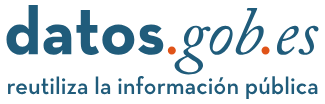

En este ejercicio, trabajaremos con dos **conjuntos de datos** publicados por el INE que detallan la [distribución de personas con un gasto elevado en vivienda por edad](https://datos.gob.es/es/catalogo/ea0010587-poblacion-con-gasto-elevado-en-vivienda-por-edad-identificador-api-79210) y [por Comunidad Autónoma](https://datos.gob.es/es/catalogo/ea0010587-poblacion-con-gasto-elevado-en-vivienda-por-comunidad-autonoma-identificador-api-79208).

Nota: estos enlaces pueden fallar con el navegador Safari. Si es el caso, probar a usar Firefox.

Un gasto elevado en vivienda se traduce a invertir el 40% o más de tus ingresos en pagar asuntos relacionados con tu vivienda, como el alquiler y las facturas. Los conjuntos de datos muestran porcentajes de personas que están en esa situación con respecto a un determinado grupo de edad o una Comunidad Autónoma en concreto.






## Conceptos iniciales de procesamiento (Explicación previa)



Los conjuntos de datos pueden presentarse en distintos formatos. Para esta práctica se ha utilizado el **JSON** (JavaScript Object Notation), un formato de texto ligero y fácil de leer que se utiliza ampliamente para intercambiar información entre aplicaciones.

Python incluye una librería estándar llamada [`json`](https://docs.python.org/3/library/json.html), que permite trabajar con este tipo de archivos de forma sencilla y eficiente. Gracias a ella, es posible convertir estructuras de datos JSON en objetos nativos de Python (como diccionarios o listas) y viceversa, facilitando así su manipulación y análisis dentro del lenguaje.


El siguiente código muestra cómo descargar y preparar el conjunto de datos en formato JSON desde la API del Instituto Nacional de Estadística (INE).

In [1]:
# Descargar el archivo JSON desde el endpoint de la API del INE
# --------------------------------------------------------------------
# El comando !wget realiza una solicitud HTTP al servidor y guarda el
# resultado en un archivo local. En este caso, se obtiene el conjunto
# de datos y se guarda con el nombre "gasto-vivienda-edad-raw.json".

!wget "https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/79210?tip=AM" -O "gasto-vivienda-edad-raw.json"

import json  # Librería estándar de Python para trabajar con archivos JSON

# --------------------------------------------------------------------
# Cargar el archivo recién descargado
# --------------------------------------------------------------------
# La función open() abre el archivo local especificando su codificación (UTF-8).
# Luego, json.load() convierte el contenido JSON en una estructura de datos
# de Python (normalmente un diccionario o una lista).
# Esto nos permite trabajar con los datos directamente en el entorno de Python.

with open("gasto-vivienda-edad-raw.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# --------------------------------------------------------------------
# Guardar una versión más legible del archivo JSON
# --------------------------------------------------------------------
# Muchos archivos JSON vienen “compactados”, sin espacios ni saltos de línea.
# Para facilitar su lectura, usamos json.dump() con los parámetros:
#   - ensure_ascii=False → mantiene los caracteres especiales (tildes, ñ, etc.)
#   - indent=4           → añade sangría de 4 espacios para formatear el contenido

# Guardar una versión más legible
with open("gasto-vivienda-edad.json", "w", encoding="utf-8") as f:
   json.dump(data, f, ensure_ascii=False, indent=4)

--2026-05-05 21:41:31--  https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/79210?tip=AM
Resolving servicios.ine.es (servicios.ine.es)... 195.254.149.35
Connecting to servicios.ine.es (servicios.ine.es)|195.254.149.35|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17817 (17K) [application/json]
Saving to: ‘gasto-vivienda-edad-raw.json’

gasto-vivienda-edad 100%[===================>]  17.40K  94.1KB/s    in 0.2s    

2026-05-05 21:41:32 (94.1 KB/s) - ‘gasto-vivienda-edad-raw.json’ saved [17817/17817]



Existen diversas páginas web que permiten visualizar y explorar archivos JSON de forma clara y estructurada.
Una de las más utilizadas es [jsonformatter.org](https://jsonformatter.org/), que muestra los datos en un formato jerárquico y legible, facilitando la comprensión de su estructura y contenido.

#### Explorando los datos del JSON:

A continuación se muestra un ejemplo práctico de como encontrar el porcentaje asociado a una determinada edad.

In [2]:
json_object = []

# Leemos el JSON
with open('gasto-vivienda-edad.json', 'r') as file:
  json_object = json.load(file)

for item in json_object:

  # Recogemos los datos para las personas comprendidas entre los 16 y los 24 años

  if item['Nombre'] == 'Población con gasto elevado en vivienda. De 16 a 24 años. Dato base. Todas las edades. ':
    data = item['Data']
    for element in data:

      if element['Anyo'] == 2024:
        print(
            'El ' + str(element['Valor']) + '% de los jóvenes de entre 16 y 24 años '
            + 'tuvieron un elevado gasto en vivienda. '
        )

print('\n')

El 6.2% de los jóvenes de entre 16 y 24 años tuvieron un elevado gasto en vivienda. 




Antes de proceder con el análisis visual, puede ser interesante realizar un preprocesamiento de la información. En el siguiente fragmento de código, se ilustra cómo deserializar un archivo JSON y filtrar su contenido para extraer una serie temporal específica.

El objetivo es transformar una estructura anidada compleja en un diccionario de Python (anyo:valor), facilitando así el acceso directo a los datos de la población joven (16-24 años) a lo largo de los distintos periodos disponibles.



In [3]:
import json

json_object = []

# Leemos el JSON
with open('gasto-vivienda-edad.json', 'r') as file:
  json_object = json.load(file)


# Almacenamos los datos para las personas comprendidas entre los 16 y los 24 años
# durante todos los periodos disponibles

jovenes_16_24 = dict()

for item in json_object:

  # El nombre contiene todas las variables de la metadata
  if item['Nombre'] == 'Población con gasto elevado en vivienda. De 16 a 24 años. Dato base. Todas las edades. ':
    data = item['Data']
    for element in data:
        anyo = element['Anyo']
        valor = element['Valor']
        jovenes_16_24[anyo] = valor

print(jovenes_16_24)


{2024: 6.2, 2023: 6.8, 2022: 8.4, 2021: 8.9, 2020: 7.3, 2019: 8.4, 2018: 9.9, 2017: 10.4, 2016: 10.8, 2015: 13.1, 2014: 13.4, 2013: 12.4, 2012: 13.7, 2011: 9.9, 2010: 12.1, 2009: 11.0, 2008: 10.5}


Por otro lado, [`Matplotlib`](https://matplotlib.org/) es una librería de Python especializada en la creación de **gráficos y visualizaciones de datos**.

Permite representar la información mediante gráficos de barras, líneas, histogramas, diagramas de dispersión y muchos otros tipos de visualizaciones.

Es una herramienta muy utilizada en ciencia de datos, ya que ayuda a transformar valores numéricos en representaciones visuales claras y fáciles de interpretar.



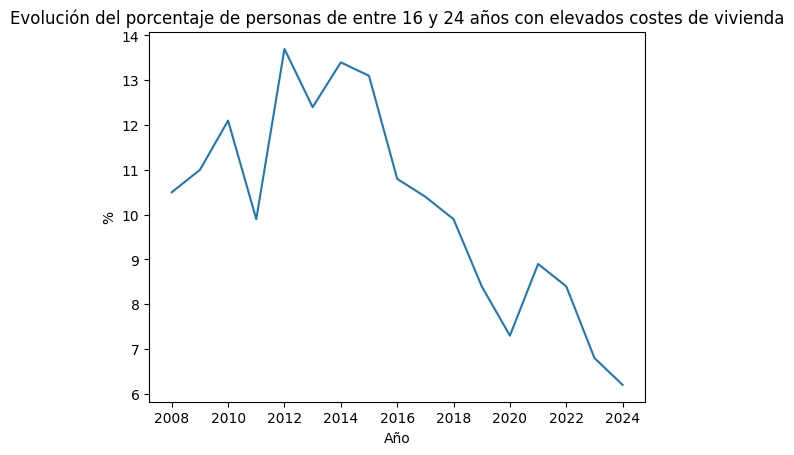

In [4]:
import matplotlib.pyplot as plt

anyos = sorted(jovenes_16_24.keys())  # Lo ordenamos
valores = [jovenes_16_24[anyo] for anyo in anyos]

plt.plot(anyos, valores)
plt.xlabel("Año")
plt.ylabel("%")
plt.title("Evolución del porcentaje de personas de entre 16 y 24 años con elevados costes de vivienda")

# Para desactivar la notación científica
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)

plt.show()


## **Apartado 1 (2/25 ptos)**

Usando el [conjunto de datos que permite agrupar los porcentajes por edades](https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/79210?tip=AM), obtén información sobre la **evolución de este porcentaje para los diferentes grupos de edad a lo largo de los años** (desde 2008 a 2024). Intenta **analizar únicamente a la población activa**, descartando el conjunto de personas de menos de 16 años.

Debes ser capaz de elaborar una gráfica como la siguiente:


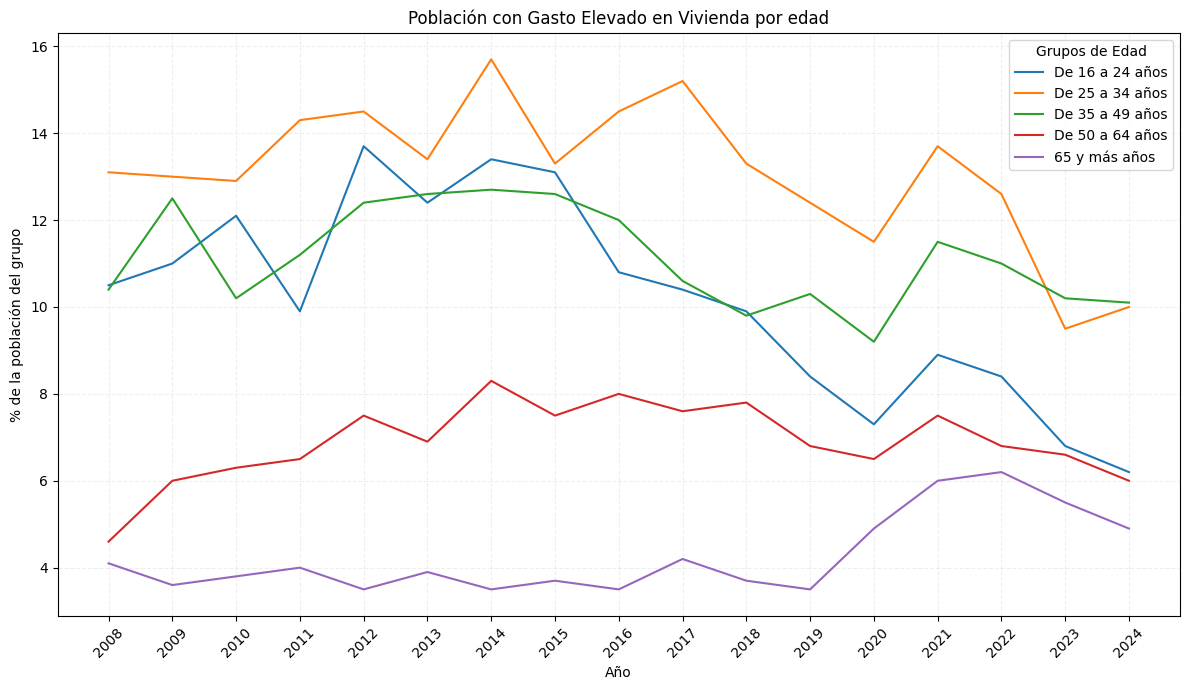


### **Tu solución**

In [5]:
import json
import matplotlib.pyplot as plt
import pandas as pd

!wget "https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/79210?tip=AM" -O "gasto-vivienda-edad-raw.json"

with open('gasto-vivienda-edad-raw.json', 'r') as file:
  json_object = json.load(file)

#  TODO: preparar los datos para su visualización

--2026-05-05 21:41:33--  https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/79210?tip=AM
Resolving servicios.ine.es (servicios.ine.es)... 195.254.149.35
Connecting to servicios.ine.es (servicios.ine.es)|195.254.149.35|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17817 (17K) [application/json]
Saving to: ‘gasto-vivienda-edad-raw.json’

gasto-vivienda-edad 100%[===================>]  17.40K  47.9KB/s    in 0.4s    

2026-05-05 21:41:36 (47.9 KB/s) - ‘gasto-vivienda-edad-raw.json’ saved [17817/17817]



In [6]:
data =json_object #metemos el json en una variable.
filas =[] #generamos una lista vacía para añadir los datos posteriormente procesados.
for i in data: #recorremos el json entero.
    if i["COD"] == "ICV1579": #buscamos el codigo correspondiente a la franja del 16-24 años en este caso.
        for d in i["Data"]:#accedemos a la lista de datos (valoires y años) del grupo en concreto.
            filas.append({"Año": d["Anyo"], "Grupo": "16-24", "Valor": d["Valor"]}) #con la funcion append añadimos a la lista: guardamos el año, asignamos el nombre y guardmaos el valor.
    elif i["COD"] == "ICV1580": #repetimos proceso para el caso25-34
        for d in i["Data"]:
            filas.append({"Año": d["Anyo"], "Grupo": "25-34", "Valor": d["Valor"]})
    elif i["COD"] == "ICV1582":#repetimos proceso para el caso35-49
        for d in i["Data"]:
            filas.append({"Año": d["Anyo"], "Grupo": "35-49", "Valor": d["Valor"]})
    elif i["COD"] == "ICV1581":
        for d in i["Data"]: #repetimos
            filas.append({"Año": d["Anyo"], "Grupo": "50-64", "Valor": d["Valor"]})
    elif i["COD"] == "ICV1578":
        for d in i["Data"]: #repetimos
            filas.append({"Año": d["Anyo"], "Grupo": "65+", "Valor": d["Valor"]})

df =pd.DataFrame(filas) #lo convertimos en un dataframe de pandas.
df_2 = df.pivot(index="Año", columns="Grupo", values="Valor") #se reorganiza el DF de la siguiente manera: los años seran las filas, las columnas los grupos y el valor los porcentajes.
df_2.head(4) #revisamo con un pequeño head

Grupo,16-24,25-34,35-49,50-64,65+
Año,,,,,
2008,10.5,13.1,10.4,4.6,4.1
2009,11.0,13.0,12.5,6.0,3.6
2010,12.1,12.9,10.2,6.3,3.8
2011,9.9,14.3,11.2,6.5,4.0


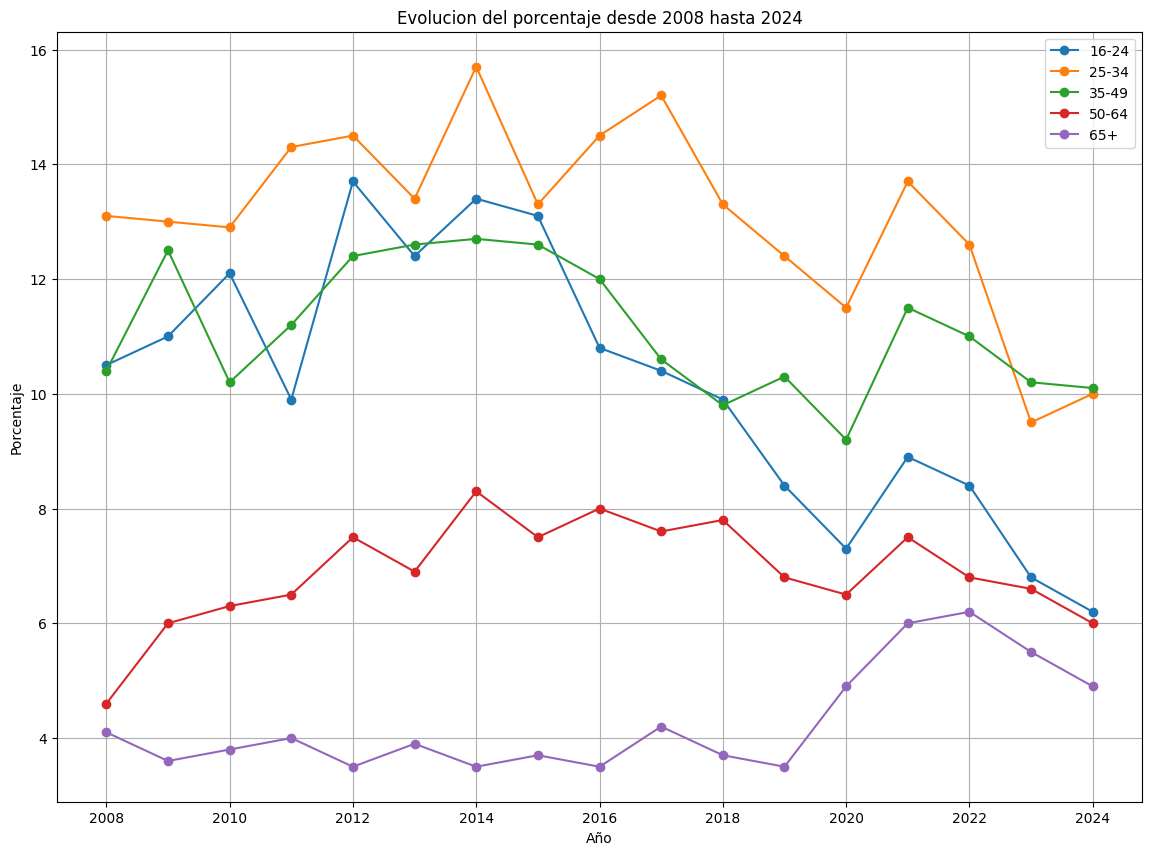

In [7]:
plt.figure(figsize=(14,10)) #aumentamos la figura.

#establecemos las diferentes gráficas por edades
plt.plot(df_2.index, df_2["16-24"], marker='o', label="16-24")
plt.plot(df_2.index, df_2["25-34"], marker='o', label="25-34")
plt.plot(df_2.index, df_2["35-49"], marker='o', label="35-49")
plt.plot(df_2.index, df_2["50-64"], marker='o', label="50-64")
plt.plot(df_2.index, df_2["65+"], marker='o', label="65+")

plt.title("Evolucion del porcentaje desde 2008 hasta 2024")
plt.xlabel("Año")
plt.ylabel("Porcentaje")
plt.legend()
plt.grid(True)

plt.show()

## **Apartado 2 (2/25 ptos)**

Usando el [conjunto de datos](https://datos.gob.es/es/catalogo/ea0010587-poblacion-con-gasto-elevado-en-vivienda-por-comunidad-autonoma-identificador-api-79208) que muestra el porcentaje de personas con un gasto elevado en vivienda por Comunidad Autónoma, en formato [JSON](https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/69497?tip=AM&), **representa los datos del año 2024 utilizando un mapa**, donde la intensidad del color indique el porcentaje: rojo para los valores máximos y amarillo para los mínimos. Debe quedar algo similar al mapa de la siguiente captura:

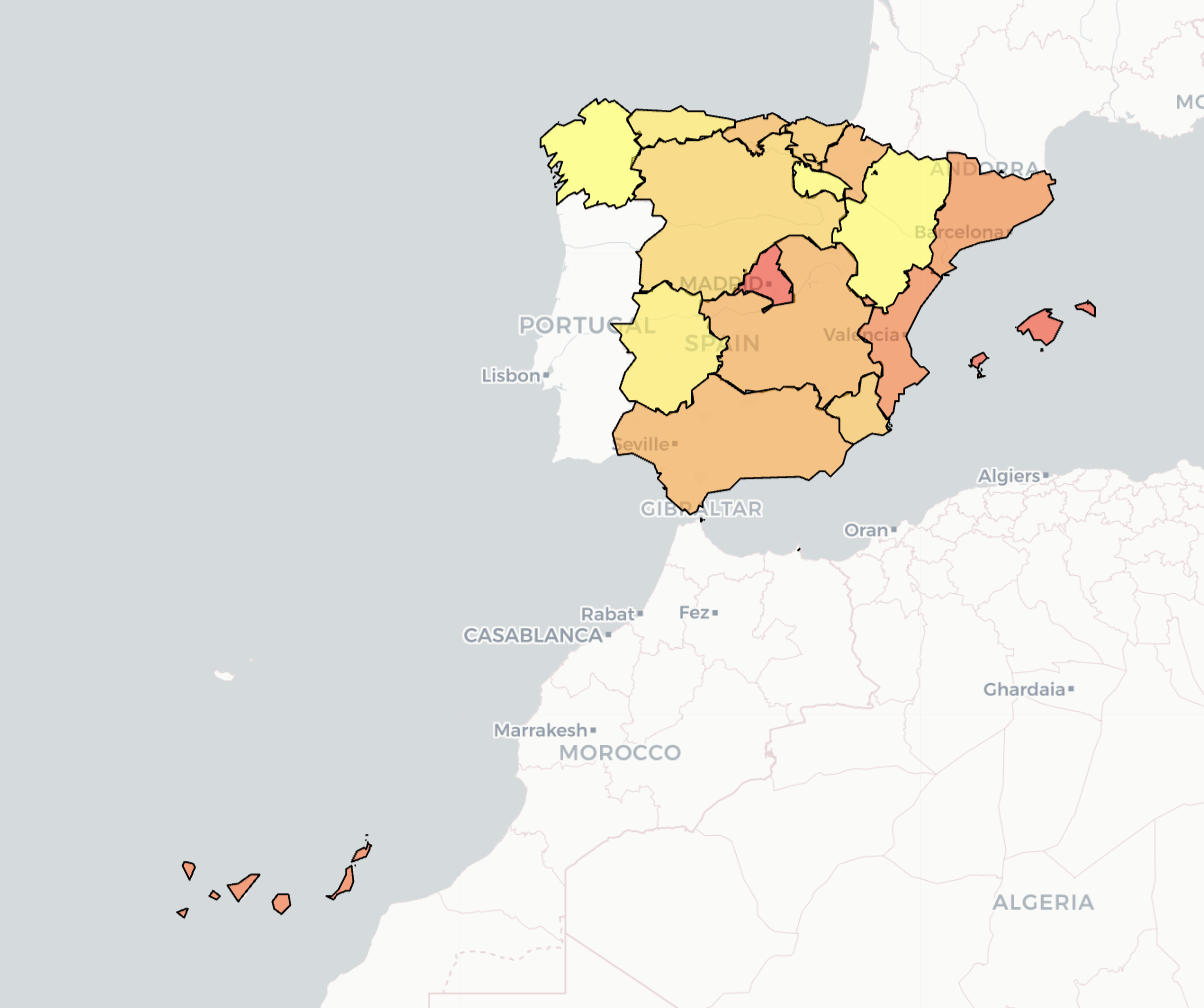

### Materiales o herramientas utilizadas (Importante)

Veremos brevemente las herramientas que se utilizaron para representar el mapa de la anterior imagen.

En este caso, utilizando `Folium` y `Branca` hemos podido construir un mapa interactivo con las Comunidades Autónomas de España. Podemos instalar ambas librerías de la siguiente manera:

In [1]:
!pip install folium
!pip install branca


   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]




[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


#### ¿Cómo funciona Branca?

Con Branca podemos crear mapas de colores. Dichos mapas permiten generar un color en base a un valor que le pasemos. El siguiente código permite ilustrar mejor el funcionamiento.

In [9]:
import branca.colormap as cm

# Creamos un colormap lineal del azul al rojo, con valores entre 0 y 100
colormap = cm.LinearColormap(
    colors=['blue', 'red'],
    vmin=0,
    vmax=100
)

# Mostramos el colormap en pantalla
# El colormap de Branca nos da un color específico para el valor que le pasemos
print("Color HEX para el valor 90: " + colormap(90))
print("Color HEX para el valor 80: " + colormap(80))
print("Color HEX para el valor 20: " + colormap(20))
print("Color HEX para el valor 20: " + colormap(10))

colormap

Color HEX para el valor 90: #e60019ff
Color HEX para el valor 80: #cc0033ff
Color HEX para el valor 20: #3300ccff
Color HEX para el valor 20: #1900e6ff


#### ¿Cómo funciona Folium?

Con Folium podemos crear mapas interactivos. El siguiente código permite generar las fronteras de cada Comunidad Autónoma en España a partir de un GeoJSON, un tipo de archivo que representa información geográfica (puntos, líneas, polígonos) en estructura JSON.

Si quieres profundizar más sobre este formato, puedes consultar la documentación oficial en [geojson.org](https://geojson.org/).

In [10]:
# Descarga del GeoJSON
!wget "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_03M_2024_4326_LEVL_2.geojson" -O 'nuts.geojson'

import folium
import json
import requests

def represent_spain(gj, propiedades_a_representar:list, aliases:list):
    gj['features'] = [
            f for f in gj['features']
            if f['properties'].get('NUTS_ID', '').startswith('ES')
    ]

    # Coordenadas aproximadas del centro de la península
    espana_coords = [39.5, -3.7]

    # Creamos el mapa centrado en España con un zoom más cercano (6)
    m = folium.Map(
        location=espana_coords,
        zoom_start=6,
        tiles="Cartodb Positron"
    )

    folium.GeoJson(
        gj,
        style_function=lambda feature: {
            # Buscamos la propiedad 'color'. Si no existe, ponemos un gris por defecto
            "fillColor": feature["properties"].get("COLOR", "#FFEA00"),
            "color": "black",
            "weight": 1,
            "fillOpacity": 0.6
        },
        tooltip=folium.GeoJsonTooltip(
            fields=propiedades_a_representar,
            aliases=aliases
        )
    ).add_to(m)

    return m

# Código principal
with open('nuts.geojson', 'r') as file:
  geojson = json.load(file)

represent_spain(geojson, ["NUTS_ID", "NUTS_NAME"], ["Código", "Nombre"])

--2026-05-05 21:41:55--  https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_03M_2024_4326_LEVL_2.geojson
Resolving gisco-services.ec.europa.eu (gisco-services.ec.europa.eu)... 13.69.248.157
Connecting to gisco-services.ec.europa.eu (gisco-services.ec.europa.eu)|13.69.248.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3906472 (3.7M) [application/geo+json]
Saving to: ‘nuts.geojson’

nuts.geojson        100%[===================>]   3.72M  2.31MB/s    in 1.6s    

2026-05-05 21:41:58 (2.31 MB/s) - ‘nuts.geojson’ saved [3906472/3906472]



Si analizamos el GeoJSON vemos que está dividido en múltiples items que vamos a llamar "feature". Una feature dentro de un archivo GeoJSON es simplemente un elemento geográfico individual. Cada feature tiene dos partes principales:

* Geometry, que describe su forma en el mapa (por ejemplo, un polígono que marca las fronteras de un país).

* Properties, que son los datos asociados a ese elemento (como el nombre del país, o su código).


En este caso, utilizando las properties, vemos que el método represent_spain() filtra solo las features basadas en España, ignorando el resto de Europa.

```
gj['features'] = [
  f for f in gj['features']
    if f['properties'].get('NUTS_ID', '').startswith('ES')
]
```

En Folium, cuando representamos el GeoJSON, el parámetros `style_function` permite asignarle un color a cada uno de esos elementos geográficos. En el código anterior, la función:

```python
style_function=lambda feature: {
            "fillColor": feature["properties"].get("COLOR", '#FFEA00'),
            "color": "black",
            "weight": 0.5,
            "fillOpacity": 0.6
      },
```

Pinta cada elemento geográfico con los datos de "COLOR" que tenga en sus propiedades. El problema es que, como hemos visto, ningun elemento tiene dicha propiedad.

También, a la hora de representar el GeoJSON, podemos especificar qué propiedades queremos resaltar cuando dejamos el ratón puesto sobre un elemento del mapa.

```python
tooltip=folium.GeoJsonTooltip(
            fields=propiedades_a_representar,
            aliases=aliases
        )
```

El `método represent_spain()` está pensado para que se le pase por parámetros el nombre de las propiedades a representar y los aliases de cada una de ellas.

### **Enunciado**

**Adaptar la información de cada feature del GeoJson correspondiente a cada Comunidad Autónoma y añade el porcentaje asociado a cada una de ellas para el año 2024**.

Es decir, para cada feature del GeoJSON que representa a una Comunidad Autónoma debes añadir:

- Una propiedad `ELEVADA_VIVIENDA` que represente el porcentaje de personas con elevado coste de vivienda para esa comunidad.

- Una propiedad `COLOR` que represente, en HEX, un color asociado a ese valor. Se puede utilizar `branca` para generar directamente el color.

Si todo sale bien, podrás utilizar el método `represent_spain()` y verás como la información se pinta de colores. Puedes apoyarte del siguiente diccionario que traduce el nombre de cada comunidad autónoma a su identificador dentro del GeoJSON:

```
{
    'Andalucía': 'ES61',
    'Aragón': 'ES24',
    'Asturias, Principado de': 'ES12',
    'Balears, Illes': 'ES53',
    'Canarias': 'ES70',
    'Cantabria': 'ES13',
    'Castilla y León': 'ES41',
    'Castilla - La Mancha': 'ES42',
    'Cataluña': 'ES51',
    'Comunitat Valenciana': 'ES52',
    'Extremadura': 'ES43',
    'Galicia': 'ES11',
    'Madrid, Comunidad de': 'ES30',
    'Murcia, Región de': 'ES62',
    'Navarra, Comunidad Foral de': 'ES22',
    'País Vasco': 'ES21',
    'Rioja, La': 'ES23',
    'Ceuta': 'ES63',
    'Melilla': 'ES64'
}

```

Siéntete libre de modificar el método `represent_spain()` si ves que no encaja con la información que le estás suministrando al JSON. Lo importante es lograr representar un mapa como el de la primera imagen.

### **Tu solución**

In [11]:
!wget "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_03M_2024_4326_LEVL_2.geojson" -O 'nuts.geojson'
!wget "https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/69497?tip=AM&" -O "gastos-vivienda-ccaa.json"

import json
import branca.colormap as cm

# Diccionario que traduce el nombre de cada comunidad en un NUTS_ID
comunidades_nuts = {
    'Andalucía': 'ES61',
    'Aragón': 'ES24',
    'Asturias, Principado de': 'ES12',
    'Balears, Illes': 'ES53',
    'Canarias': 'ES70',
    'Cantabria': 'ES13',
    'Castilla y León': 'ES41',
    'Castilla - La Mancha': 'ES42',
    'Cataluña': 'ES51',
    'Comunitat Valenciana': 'ES52',
    'Extremadura': 'ES43',
    'Galicia': 'ES11',
    'Madrid, Comunidad de': 'ES30',
    'Murcia, Región de': 'ES62',
    'Navarra, Comunidad Foral de': 'ES22',
    'País Vasco': 'ES21',
    'Rioja, La': 'ES23',
    'Ceuta': 'ES63',
    'Melilla': 'ES64'
}

# 1. Cargamos el geojson
with open('nuts.geojson', 'r') as file:
  geojson = json.load(file)

# Cargamos los datos en formato json
with open('gastos-vivienda-ccaa.json', 'r') as file:
  json_object = json.load(file)

--2026-05-05 21:41:59--  https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/NUTS_RG_03M_2024_4326_LEVL_2.geojson
Resolving gisco-services.ec.europa.eu (gisco-services.ec.europa.eu)... 13.69.248.157
Connecting to gisco-services.ec.europa.eu (gisco-services.ec.europa.eu)|13.69.248.157|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3906472 (3.7M) [application/geo+json]
Saving to: ‘nuts.geojson’

nuts.geojson        100%[===================>]   3.72M  3.15MB/s    in 1.2s    

2026-05-05 21:42:01 (3.15 MB/s) - ‘nuts.geojson’ saved [3906472/3906472]

--2026-05-05 21:42:01--  https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/69497?tip=AM&
Resolving servicios.ine.es (servicios.ine.es)... 195.254.149.35
Connecting to servicios.ine.es (servicios.ine.es)|195.254.149.35|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50984 (50K) [application/json]
Saving to: ‘gastos-vivienda-ccaa.json’

gastos-vivienda-cca 100%[=============

In [12]:
valores_ccaa = {} #creamos un diccionario vacío para guardar provincias con sus puntuaciones
#comunidades_nuts

"""
A continuación accedemos al json para acceder a sus datos y puntuar cada comunidad autonoma en el diccionario.
clave=nombre comunidad
valor=puntuacion.
"""

for i in json_object: #recorremos el json.
    nombre =i["Nombre"] #accedemos al nombre de cada comunidad.
    for d in i["Data"]: #recorremos los datos internos que son (años, valores etc)
        if d["Anyo"] ==2024: #si el año coincide con 2024 entonces:
            valores_ccaa[nombre] =d["Valor"] #añadimos el valor al diccionarioo previio.
"""
A continuación, vamos a diseñar el color del mapa de colores que representará las puntuaciones de cada comunidad autónoma.
Será una escala de amarillo menor a rojo mayor.
"""

colormap = cm.LinearColormap(colors=["yellow", "red"], vmin=6,vmax=9) #se ajusta el intervalo a los datos correctos.

"""
A continuación, recorremos cada comunidad y asignamos la comunidad correspondiente que toque.
"""

#Recorremos cada comunidad del geosojon
for i in geojson["features"]: #recorremos las features o regiones geogrqficas del geojson
    nuts_id = i["properties"]["NUTS_ID"] #sacamos el identificativo de cada comunidad autonoma (es170 baleares, es142 etc)
    valor = None #variable vacía para guardar el valor

    #Buscar la comunidad correspondiente al nuts
    for comunidad, codigo in comunidades_nuts.items(): #recorremos el diccionario sacando la clave (comunidad) y el valor (codigo) em el diccionario comunidades_nuts
        if codigo ==nuts_id:#si el codigo nut coincide con los id snuts_id = i["properties"]["NUTS_ID"] entonces:
            for nombre_ine, v in valores_ccaa.items(): #Buscamos los datos del INE con clave y valor del diccionario que hemos sacado
                if comunidad in nombre_ine: #buscamos coincidencias parciales entre texto
                    valor = v #asignmamos el valor a la variable
                    break  #salimos porque ya encontramos el valor

            break  #salimos porque ya encontramos la comunidad
    """
    A continuación, vamos asignanmos los valores correspondientes a cada comunidad.
    """
    if valor is not None:
        i["properties"]["ELEVADA_VIVIENDA"] =valor
        i["properties"]["COLOR"] =colormap(valor)
    else:
        i["properties"]["ELEVADA_VIVIENDA"] ="Sin datos"
        i["properties"]["COLOR"] ="#cccccc"

In [13]:
represent_spain( #repsentamos
    geojson,
    ["NUTS_ID", "NUTS_NAME", "ELEVADA_VIVIENDA"],
    ["Código", "Nombre", "% de personas con elevado coste de vivienda"]
)

## **Apartado 3 (2,5/25 ptos)**



Los datos utilizados en los ejercicios *anteriores* provienen del INE (Instituto Nacional de Estadística), específicamente de la sección [Indicadores de la Calidad de Vida](https://www.ine.es/dynt3/inebase/index.htm?padre=11249&capsel=11250), una fuente esencial para medir el bienestar de la sociedad española.

En este apartado, se propone realizar un **análisis libre** y exploratorio sobre cualquier otro conjunto de datos disponible en **dicha sección**. A diferencia de las tareas previas, dispones de autonomía para elegir la variable a estudiar y su metodología de representación, aplicando los conocimientos adquiridos sobre tratamiento, filtrado y visualización de datos JSON.

Requisitos del trabajo:

- Desarrollo técnico: Documentar el proceso completo (selección del dataset, limpieza, filtrado y transformación).
   - Puedes elegir libremente el tipo de visualización o reutilizar recursos previos.
   - La obtención/descarga del conjunto de datos se hará directamente desde el código, tal como se indica en el siguiente apartado.

- Informe de conclusiones: Redactar una interpretación de los resultados y los hallazgos principales. Extensión máxima: 15 líneas.

Criterios de evaluación:

- Rigor técnico: Precisión en el tratamiento de los datos y pertinencia de la visualización elegida.

- Profundidad del análisis: Capacidad para extraer información de valor y coherencia en el enfoque.

- Capacidad de síntesis: Claridad y precisión expositiva dentro del límite de extensión establecido.

### ¿Como obtener los datasets en formato JSON?


Darle al icono de descarga del conjunto de datos seleccionado.

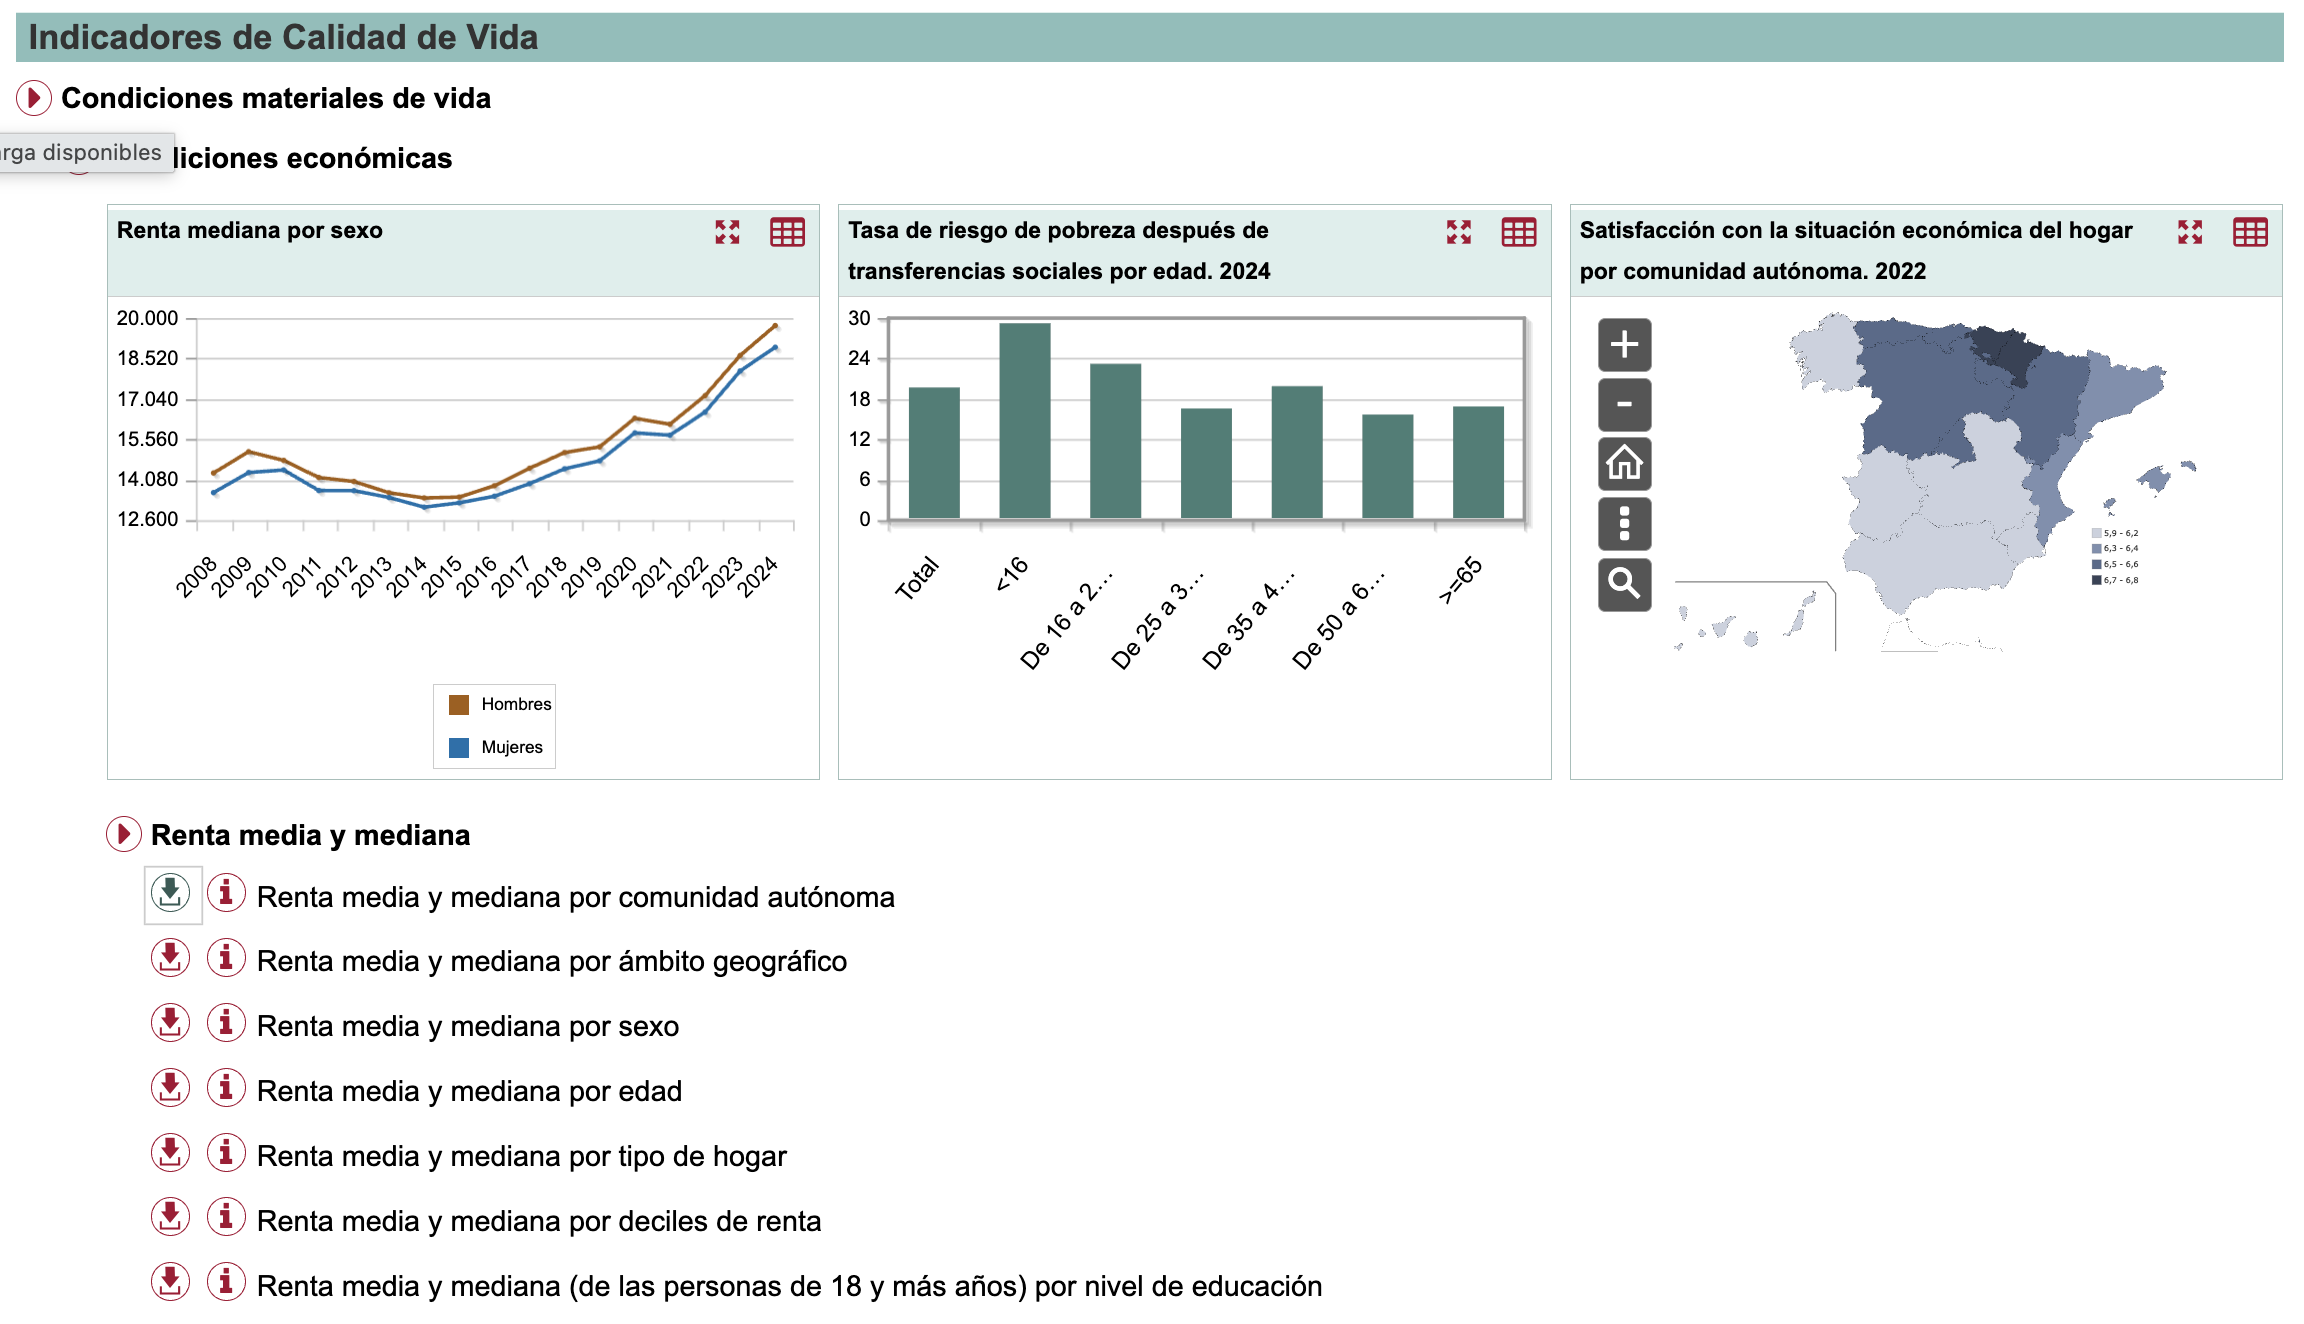

Entre los formatos disponibles, selecciona JSON. Haz clic derecho sobre el enlace y elige 'Copiar dirección de enlace'. A continuación, **descarga el archivo directamente en tu notebook** ejecutando el comando !wget de la siguiente manera:

!wget url -O "nombre.json"


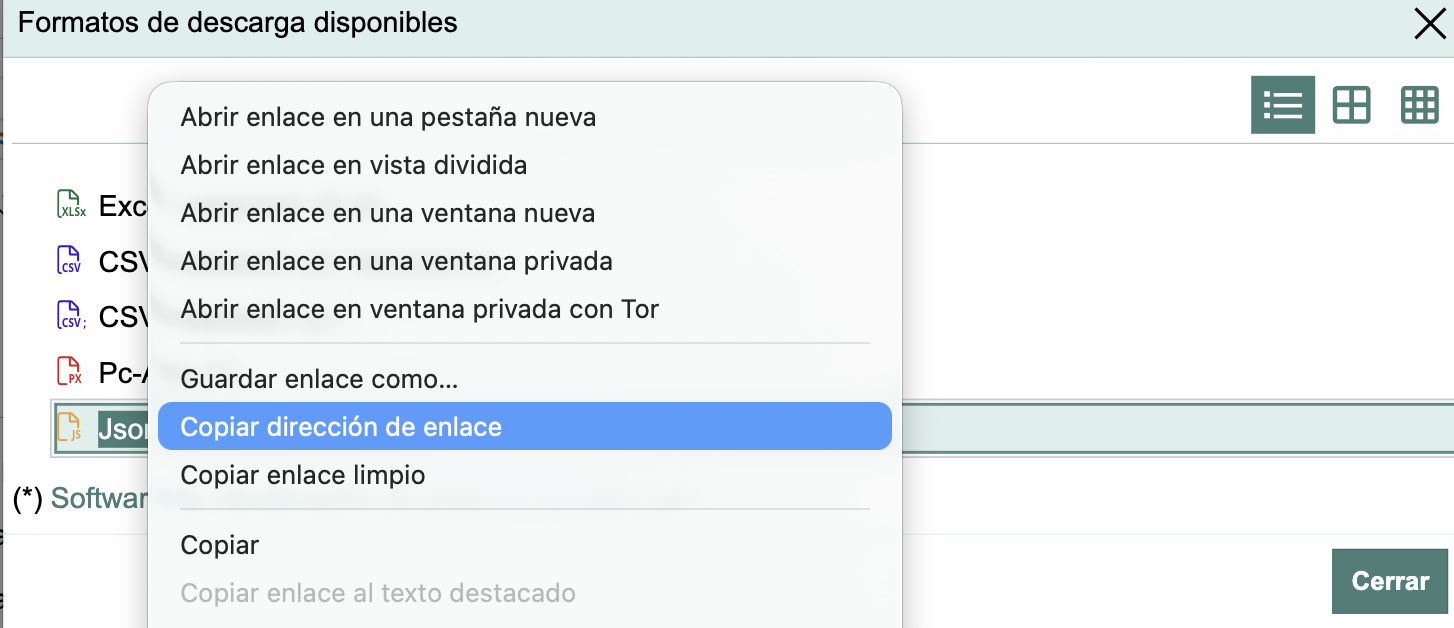

In [14]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt


!wget "https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/69771?tip=AM" -O "nivel-formacion-edad.json"

with open('nivel-formacion-edad.json', 'r') as file:
    json_object_2 = json.load(file)
print(json_object_2)

#Hemos deciddio coger el dataset sobre el nivel de estudios por rango de edad para realizar un pequeño estudio sobre él.

--2026-05-05 21:42:02--  https://servicios.ine.es/wstempus/jsCache/es/DATOS_TABLA/69771?tip=AM
Resolving servicios.ine.es (servicios.ine.es)... 195.254.149.35
Connecting to servicios.ine.es (servicios.ine.es)|195.254.149.35|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 61140 (60K) [application/json]
Saving to: ‘nivel-formacion-edad.json’

nivel-formacion-eda 100%[===================>]  59.71K   164KB/s    in 0.4s    

2026-05-05 21:42:03 (164 KB/s) - ‘nivel-formacion-edad.json’ saved [61140/61140]

[{'COD': 'ICV127', 'Nombre': 'Primera etapa de educación secundaria e inferior. De 16 a 64 años. Dato base. De 16 a 64 años. ', 'T3_Unidad': 'Porcentaje', 'T3_Escala': ' ', 'MetaData': [{'Id': 291078, 'T3_Variable': 'Nivel de formación alcanzado', 'Nombre': 'Nivel (0-2): preescolar, primaria y secundaria de 1ª etapa', 'Codigo': 'A'}, {'Id': 283906, 'T3_Variable': 'Grupos de edad', 'Nombre': 'De 16 a 64 años', 'Codigo': 'Y16T64'}, {'Id': 72, 'T3_Variable': 'Tipo de

In [15]:
filas = [] #generamos la lista correspondiente.

for i in json_object_2: #recorremos el json
    nombre = i["Nombre"] #buscamos coincidencia de nombre para encontrar los rangos de edad.
    """
    Buscamos los diferentes rangos de edad.
    """
    if "16 a 24" in nombre:
        grupo = "16-24"
    elif "25 a 34" in nombre:
        grupo = "25-34"
    elif "35 a 49" in nombre:
        grupo = "35-49"
    elif "50 a 64" in nombre:
        grupo = "50-64"
    else:
        grupo = "Total"
    """
    Establecemos los rangos de estudios:
    primera etapa: educacion secuandaria o menos
    segunda etapa: bachillerato o fp medio
    educación superior: fp superior, grado o superior
    """
    if "primera etapa" in nombre.lower():
        nivel = "Inferior"
    elif "segunda etapa" in nombre.lower():
        nivel = "Medio"
    elif "educación superior" in nombre.lower():
        nivel = "Superior"
    else:
      continue  #saltamos filas que no encajan

    for d in i["Data"]: #recorremos los datos anuales (años yvalores), generamos las filas y el formato adecuaco respecto año, grupo y nivel
        filas.append({"Año": d["Anyo"],"Grupo": grupo,"Nivel": nivel,"Valor": d["Valor"]})

df = pd.DataFrame(filas) #añadimos a una df de pandas
df_2 =df.pivot_table(index="Año",columns=["Grupo", "Nivel"],values="Valor") #generamos el df de la forma correcta como queremos presentarlo

df_2.head() #revisamos

Grupo    16-24                   25-34                   35-49                 \
Nivel Inferior Medio Superior Inferior Medio Superior Inferior Medio Superior   
Año                                                                             
2004      53.8  33.0     13.2     37.7  23.3     39.0     53.0  20.7     26.3   
2005      53.9  32.7     13.5     35.5  23.8     40.7     49.4  22.7     28.0   
2006      53.7  32.8     13.4     35.2  24.5     40.3     48.0  23.1     28.8   
2007      54.4  32.6     13.0     34.6  25.4     40.0     46.9  23.2     29.9   
2008      55.2  32.0     12.9     34.3  25.7     40.0     46.6  23.2     30.3   

Grupo    50-64                   Total                 
Nivel Inferior Medio Superior Inferior Medio Superior  
Año                                                    
2004      74.9  10.7     14.4     54.5  21.0     24.5  
2005      70.5  13.1     16.4     51.7  22.3     26.1  
2006      69.2  14.0     16.8     50.9  22.8     26.4  
2007      67.9  14.7     17.4     50.1  23.1     26.8  
2008      66.7  15.3     18.0     49.8  23.1     27.0

In [16]:
df_check = df_2.groupby(level=0, axis=1).sum() #check que coinciden todos los datos.
df_check.head()

/tmp/ipykernel_177/309424935.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_check = df_2.groupby(level=0, axis=1).sum() #check que coinciden todos los datos.


Grupo,16-24,25-34,35-49,50-64,Total
Año,,,,,
2004,100.0,100.0,100.0,100.0,100.0
2005,100.1,100.0,100.1,100.0,100.1
2006,99.9,100.0,99.9,100.0,100.1
2007,100.0,100.0,100.0,100.0,100.0
2008,100.1,100.0,100.1,100.0,99.9


<Figure size 800x400 with 0 Axes>

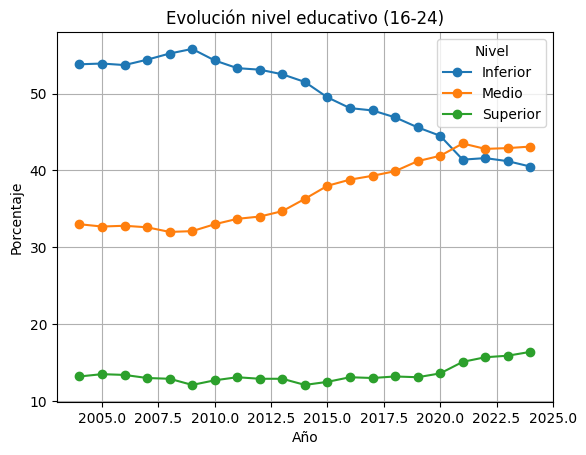

<Figure size 800x400 with 0 Axes>

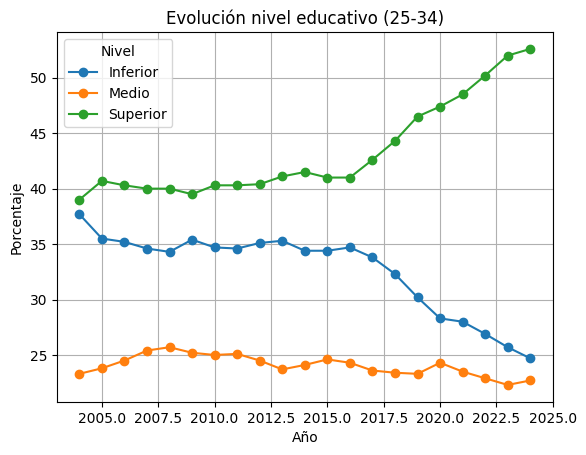

<Figure size 800x400 with 0 Axes>

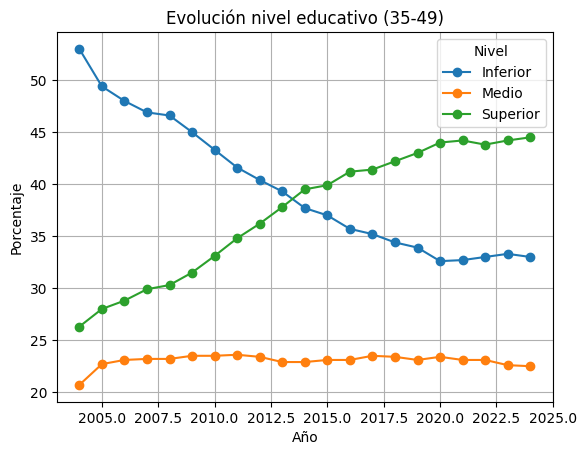

<Figure size 800x400 with 0 Axes>

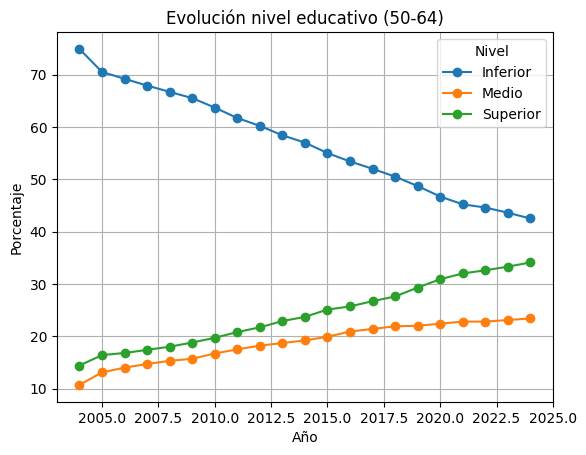

<Figure size 800x400 with 0 Axes>

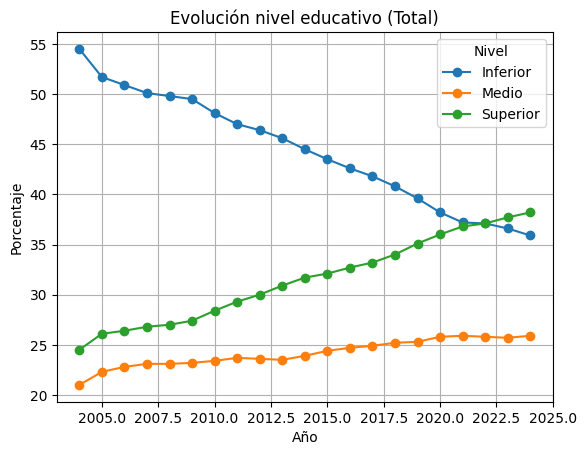

In [17]:
grupos =df_2.columns.levels[0]

for i in grupos: #generamos un grafico para cada rango de edad e interpretamos.
    df_3 = df_2[i]
    plt.figure(figsize=(8,4))
    df_3.plot(marker='o')
    plt.title(f"Evolución nivel educativo ({i})")
    plt.ylabel("Porcentaje")
    plt.xlabel("Año")
    plt.grid(True)
    plt.legend(title="Nivel")
    plt.show()

Educación Superior: Vemos que tiene un crecimiento fuerte en todos los grupos de edad. Más ligero entre 16-24 debido a las limitaciones en tiempo de la educación superior en esa franja de edad.
  
Eduación media: Vemos que crece ligeramente o se mantiene estable en todos los grupos de edad. No concluimos nada.
  
Educación básica: vemos que decrece en todos los grupos de edad. Supone que como estudios máximos pierde conforme pasan los años.
Estas gráficas reflejan una mejora estructural fuerte en el sistema educativo. La mejora económica, digitalización y democratización de la enseña ayudan a mejorar el nivel educativo de la población.
  
Podemos comprobar que existen pequeñas perturbaciones en algunos gráficos de mediana edad en años puntuales como 2008 o 2020 curiosamente.

# **Ejercicio 2 - Introducción al Web Scraping: extracción automatizada de datos (3,5/25 ptos)**




En la actualidad, gran parte de la información disponible en Internet no está pensada para ser descargada o analizada directamente, sino que se presenta dentro de páginas web diseñadas para usuarios humanos. Sin embargo, los analistas y científicos de datos suelen necesitar acceder a esa información de forma estructurada para poder procesarla, compararla o integrarla en otros sistemas.

El web scraping surge precisamente como una técnica que automatiza la recolección de datos desde páginas web, permitiendo transformar el contenido visible (HTML) en datos organizados y analizables (por ejemplo, en formato CSV, JSON o en un DataFrame de pandas).


#### Ejemplos de uso real
- Extraer información de catálogos de productos (precios, títulos, valoraciones, disponibilidad...).
- Recoger datos de ofertas de empleo, vuelos o alojamientos para comparar tendencias.
- Obtener titulares o noticias para análisis de texto o minería de datos.
- Monitorizar cambios de precios o contenidos en páginas de interés.


En este ejercicio realizaremos una extracción de datos desde un par de webs. La primera de ellas es una tienda online de libros simulada, creada específicamente con fines educativos y de práctica en web scraping:

https://books.toscrape.com/index.html

Esta web es un sitio diseñado para aprender y experimentar con técnicas de extracción de datos sin infringir políticas de uso o derechos de autor.
Su estructura está pensada para reproducir el funcionamiento de una tienda real: incluye títulos, precios, valoraciones y disponibilidad de libros, presentados de forma similar a cualquier comercio electrónico.

## Conceptos iniciales de Web Scraping (Explicación previa)

Veamos como hacer una primera extracción de un producto en la página.

Los navegadores modernos presentan una opción llamada [**Herramientas para desarrolladores**](https://medium.com/swlh/the-basics-of-chrome-devtools-4d69a102a699) que proporciona información extremadamente útil para comprender cómo funcionan las peticiones web de una página. En Chrome, por ejemplo, podemos encontrar dicha opción yendo a `Más herramientas > Herramientas para desarrolladores`.

Lo **primero** que debemos hacer es **explorar brevemente la página para entender cómo se estructura el html**. Si inspeccionamos el título, vemos que para cada libro dicho elemento se encuentra en una etiqueta `<h3>`.

Los elementos parecen encontrarse dentro de una lista ordenada `<ol>` que tiene la clase `row`.

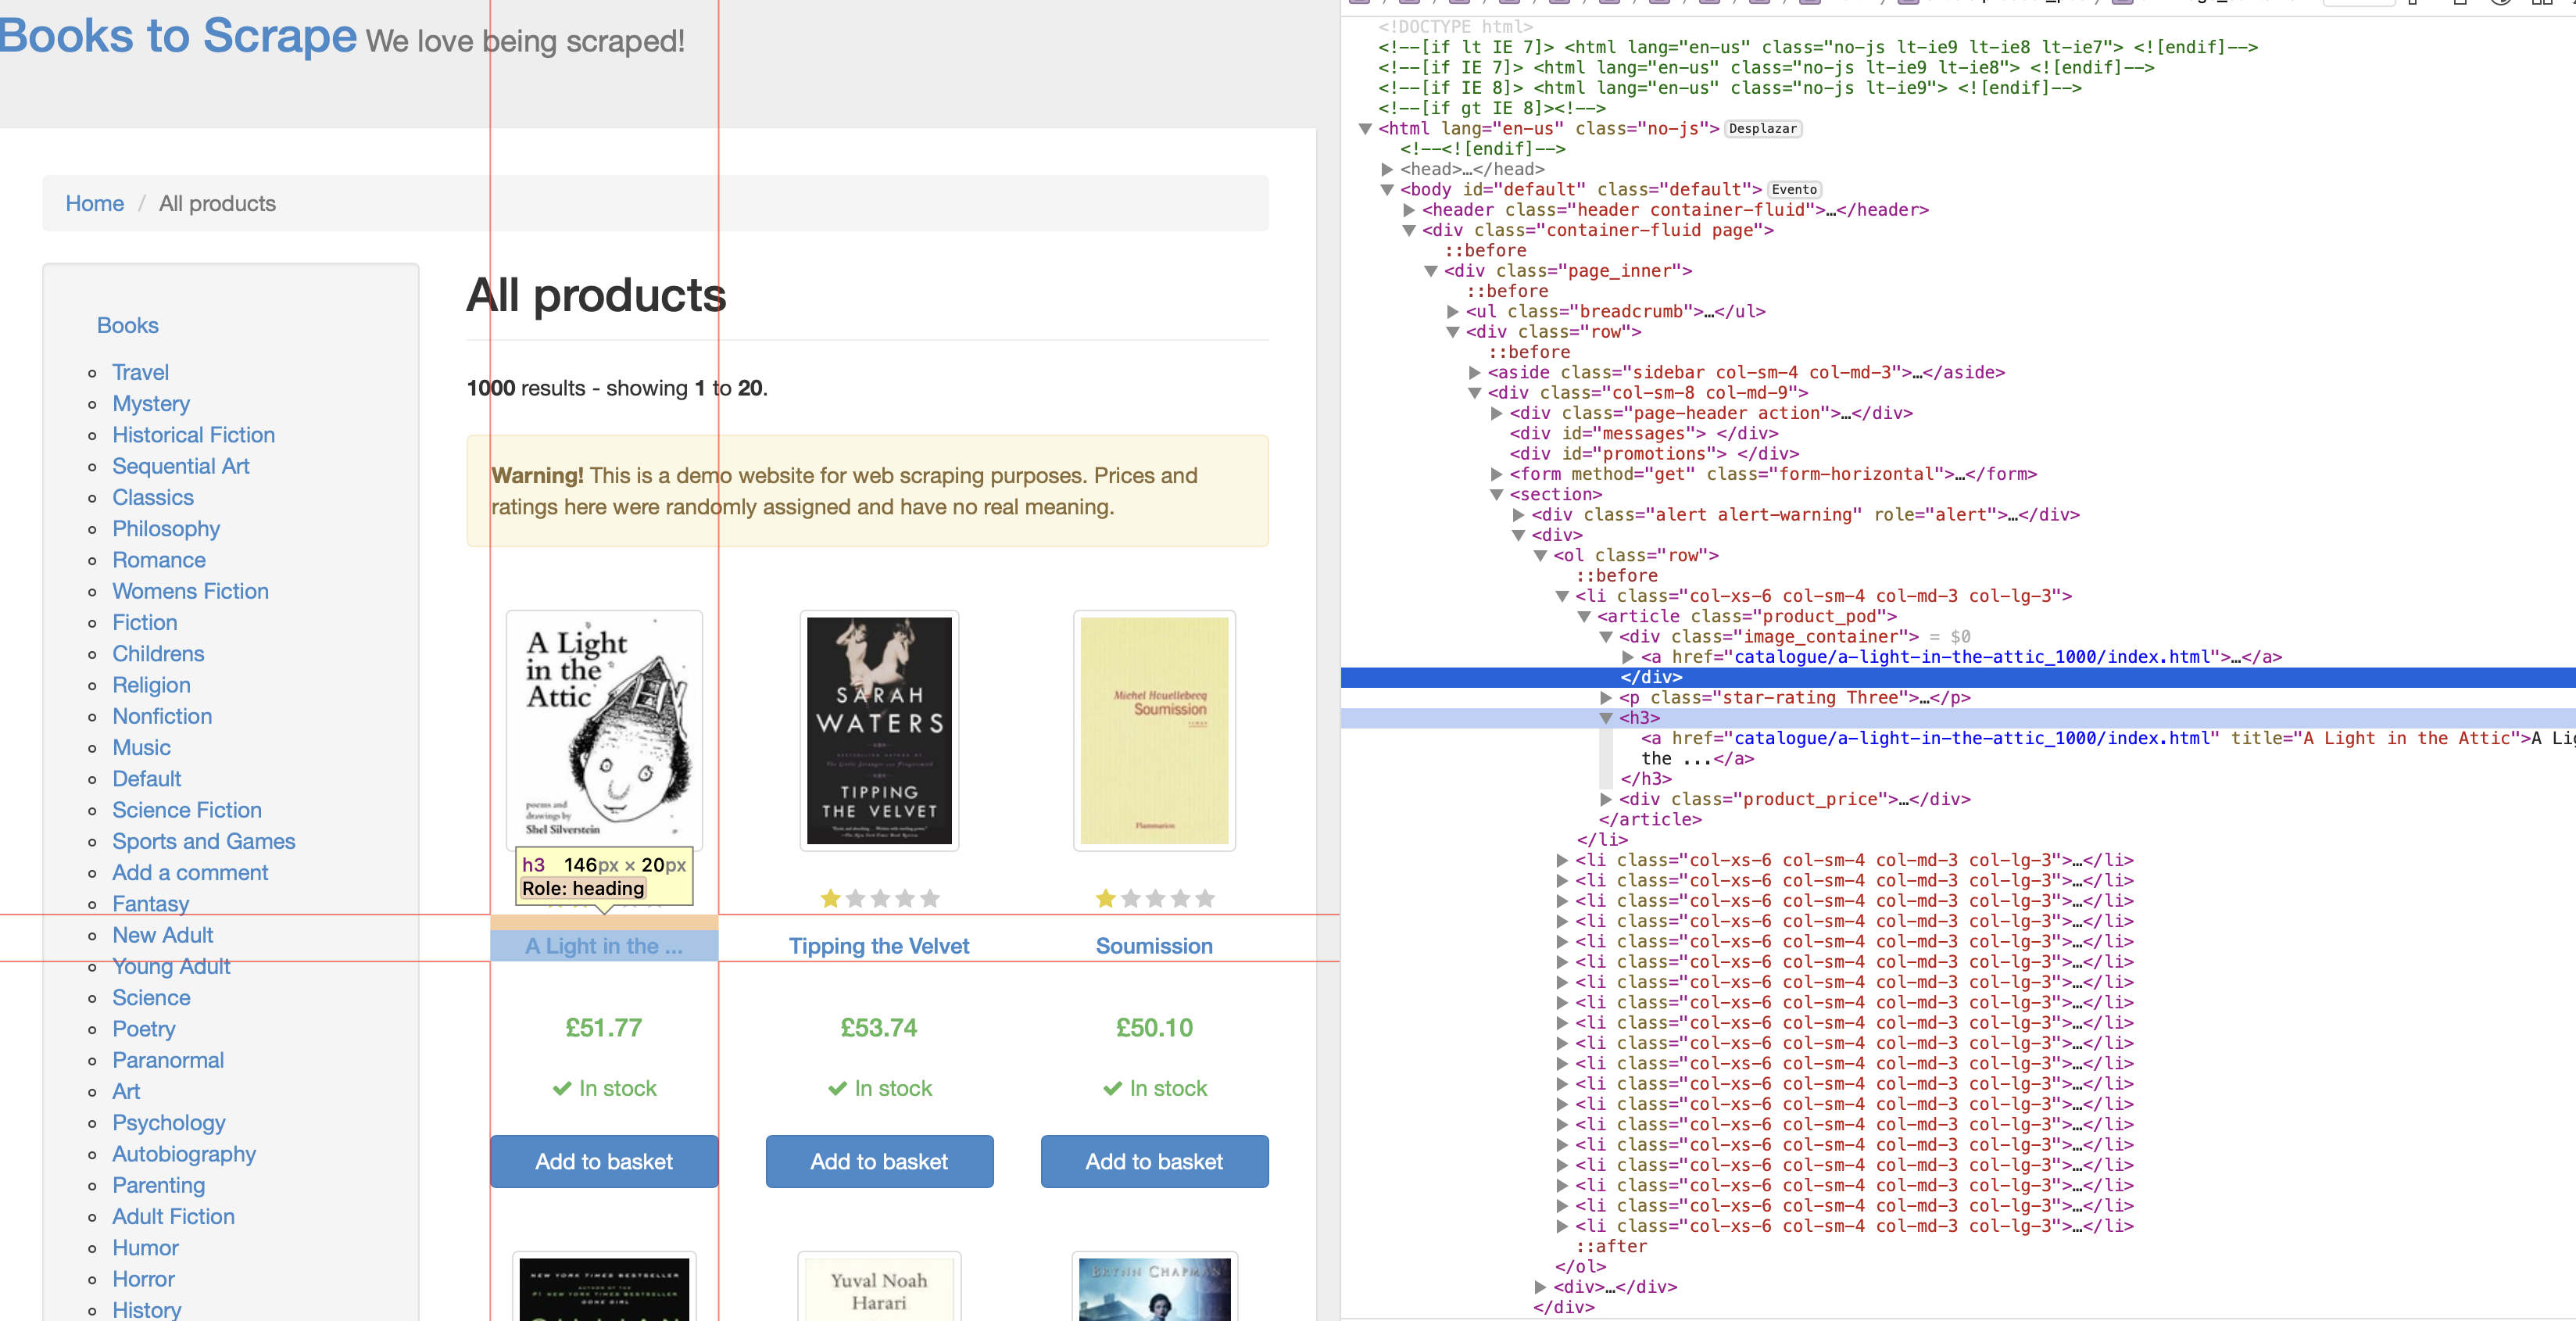

El **segundo paso** es **obtener** dicha información. Una de las librerías más populares en Python para hacer peticiones a un servidor es [**`requests`**](https://requests.readthedocs.io/en/latest/). La podemos instalar de la siguiente manera:

In [18]:
!pip install requests

Para obtener el html, bastará con hacer una petición a la URL y guardar su respuesta.

In [19]:
import requests

response = requests.get('https://books.toscrape.com/index.html')

if response.status_code == 200:
  content = response.content
  print(content)

b'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon" hre

El siguiente paso será parsear el html, otra librería muy popular es **`BeautifulSoup`**, que permite esto mismo. La instalamos en nuestro entorno:

In [20]:
!pip install bs4

Podemos ver la documentación de dicha librería en el siguiente [enlace](https://www.crummy.com/software/BeautifulSoup/bs4/doc/). Concretamente, para obtener el `<h3>` de cada producto:

In [21]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(content, 'html.parser')

ordered_list = soup.find('ol', class_='row')
# Con find_all() obtenemos un listado con todos los elementos
books = ordered_list.find_all('li')
for book in books:

  # Con find() obtenemos el primer elemento que cumpla con los requisitos
  title = book.find('h3')
  print(title.text)


A Light in the ...
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History ...
The Requiem Red
The Dirty Little Secrets ...
The Coming Woman: A ...
The Boys in the ...
The Black Maria
Starving Hearts (Triangular Trade ...
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little ...
Rip it Up and ...
Our Band Could Be ...
Olio
Mesaerion: The Best Science ...
Libertarianism for Beginners
It's Only the Himalayas


No obstante, vemos que **los título no se llegan a imprimir correctamente y parecen cortado**s. Si observamos la estructura html con detenimiento, veremos que el título completo se encuentra en el atributo `title` dentro del enlace a la página de detalles de cada libro.

In [22]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(content, 'html.parser')


ordered_list = soup.find('ol', class_='row')
books = ordered_list.find_all('li')
for book in books:

  title = book.find('h3')
  link = title.find('a')

  if link:
    print(link['title'])

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


# Enunciado (3,5/25 ptos)


Utilizando las librerías mencionadas previamente, el objetivo de este ejercicio es realizar un proceso completo de extracción y procesamiento de datos desde la [web Books to Scrape](https://books.toscrape.com/index.html)

Requisitos:

- Extracción de Categorías: Identifica y extrae el listado completo de categorías que aparecen en el menú lateral de la página principal.

- Procesamiento por Categoría: Para cada categoría, debes navegar por todas sus páginas disponibles y extraer la valoración (rating) de cada libro.

- Cálculo de la Media: Calcula la valoración media de cada categoría aplicando la siguiente fórmula

$$\frac{\text{Suma de las valoraciones de todos los libros de la categoría}}{\text{Total de libros de la categoría}}$$

- Filtrado de Datos: Únicamente deben incluirse en el resultado final aquellas categorías que contengan 10 libros o más.

- Ordenación: El listado final debe mostrarse ordenado de mayor a menor en función de la nota media obtenida.


**Formato de salida**:

La información debe mostrarse por pantalla con el siguiente formato, asegurando que la media se exprese con exactamente dos decimales:

Categoría: [Nombre] | Media: [Valor] | Libros: [Cantidad]

Es importante que la valoración se exprese con **dos decimales únicamente**.

```
Categoría: Poetry | Media: 3.53 | Libros: 19
```


### **Tu solución**

In [ ]:
import requests
from bs4 import BeautifulSoup

base_url = "http://books.toscrape.com/"
response = requests.get(base_url) #peticion requests
soup = BeautifulSoup(response.text, "html.parser") #parseamos html
cod_fuente_categori = soup.find("ul", class_="nav nav-list").find("ul") #BUSCAMOS el bloque de las categorías.
rating_dict = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5} #establecemos los ratings de las categorias.
resultados = [] #lista donde guardaremos los resultados finales.
for i in cod_fuente_categori.find_all("li"): #recorremos todos los elementos <li> de las caategorias
    categoria =i.find("a").text.strip() #cogemos los nombres de las categorias sin espacios etc
    url_categoria =base_url + i.find("a")["href"]
    response = requests.get(url_categoria) #peticion
    soup = BeautifulSoup(response.text, "html.parser") #parsear
    libros = soup.find_all("article", class_="product_pod") #buscamos todos los libros de la categoría en específico.
    ratings = [] #lista vacia para añadir los ratings.
    for l in libros: #recorremos todos los librros
        rating_texto = l.find("p")["class"][1] #extraemos el rating del texto.
        rating = rating_dict[rating_texto] #convertimos a rating a número de diccionario
        ratings.append(rating) #añadimos con la funcion append
    total_libros = len(ratings) #contamos el total de libros.
    if total_libros >= 10: #aplicamos condicion si es mayor que 10 como pide el enunciado
        media = sum(ratings) / total_libros #entonces calculamos la media
        resultados.append((categoria, media, total_libros)) #añadimos con la funcio append.

resultados.sort(key=lambda x: x[1], reverse=True) #ordenamos

for categoria, media, total in resultados: #mostramos
    print(f"Categoría: {categoria} | Media: {media:.2f} | Libros: {total}")

# **Ejercicio 3 - Acceso a datos abiertos por API (8,5/25 ptos)**


Una API (Application Programming Interface) es un mecanismo que permite a diferentes aplicaciones comunicarse entre sí para solicitar o intercambiar información. Su función es estandarizar la manera en que un programa puede acceder a los datos o servicios de otro sistema. Las APIs de datos públicos son interfaces que permiten acceder de manera estructurada y automatizada a la información que ofrecen organismos e instituciones.

En este apartado se explorará cómo trabajar con varias API de datos públicos, atendiendo a sus características principales, las consideraciones técnicas necesarias y ejemplos de posibles aplicaciones prácticas que aprovechan la información disponible.

## Conceptos iniciales sobre el consumo de APIs (Explicación previa)


Una API (Application Programming Interface) ofrece distintos endpoints, que son direcciones URL diseñadas para acceder a recursos o datos concretos de un servicio.
Cada endpoint define una ruta específica y devuelve un tipo de información determinado, normalmente en formato JSON.

Al consumir una API, se establecen peticiones hacia esos endpoints y se procesan las respuestas para integrar los datos obtenidos en aplicaciones o flujos de trabajo.

Vamos a explorar algun ejemplo de API y ver cómo hacer peticiones.

### [JSONPlaceholder](https://jsonplaceholder.typicode.com/)

Es una API de práctica, pensada para aprender a hacer peticiones y probar como funcionan. No usa datos reales, sino datos de ejemplo.

Dispone de varios endpoints, que permiten trabajar con distintos recursos:

* Publicaciones: `https://jsonplaceholder.typicode.com/posts`

  Devuelve una lista de publicaciones de ejemplo.

* Comentarios: `https://jsonplaceholder.typicode.com/comments`

  Muestra los comentarios disponibles.

* Usuarios: `https://jsonplaceholder.typicode.com/users`

  Devuelve una lista de usuarios de ejemplo.

In [ ]:
import requests

# Obtenemos todas las publicaciones
response = requests.get('https://jsonplaceholder.typicode.com/posts')
if response.status_code == 200:
  print('Publicaciones: ')
  print(response.json())

# Obtenemos todos los comentarios
response = requests.get('https://jsonplaceholder.typicode.com/comments')
if response.status_code == 200:
  print('Comentarios: ')
  print(response.json())

# Obtenemos todos los comentarios
response = requests.get('https://jsonplaceholder.typicode.com/users')
if response.status_code == 200:
  print('Usuarios: ')
  print(response.json())

También es habitual en las APIs enviar parámetros. Un parámetro es un dato extra que añadimos a la petición para filtrar o personalizar la respuesta. Por ejemplo, el siguiente código devuelve las publicaciones del usuario con el ID 1.

In [ ]:
import requests

# Obtenemos las publicaciones del usuario con el ID 1
params = {
    'userId': 1
}

response = requests.get('https://jsonplaceholder.typicode.com/posts', params=params)
if response.status_code == 200:
  print('Publicaciones del usuario 1')
  print(response.json())

### Documentación

Muchas APIs que encontramos en Internet tienen documentación disponible. En ella se explica qué endpoints existen, qué parámetros se pueden usar y qué tipo de respuestas devuelve la API. Esta información es fundamental para saber cómo construir correctamente las peticiones y entender los datos que recibimos. Además, suele incluir ejemplos prácticos que facilitan el aprendizaje y la integración en proyectos reales.


## **Apartado 1 - Consulta a la API de Open-Meteo y visualización de temperaturas (2,5/25 ptos)**



El objetivo de este apartado es desarrollar un script de Python que consuma datos reales de la API de [Open-Meteo](https://open-meteo.com/en/docs) para analizar cómo varían las temperaturas en tu ciudad, comparando los registros pasados con la tendencia prevista para los próximos días.

####Requisitos del ejercicio:

1. Consulta a la API:


   - Configura la petición para obtener datos basados en las coordenadas geográficas (latitud y longitud) de tu ciudad.

   - Rango temporal: La consulta debe abarcar un **periodo total de 15 días**: los 7 días previos, el día actual y la previsión de los 7 días posteriores. Consulta la [documentación](https://open-meteo.com/en/docs) de la API para ajustar los parámetros necesarios.

2. Tratamiento de datos con Pandas:

   - Utiliza la librería pandas para cargar la respuesta de la API en un objeto DataFrame.

   - Establece la columna de tiempo como índice del DataFrame, asegurando que las fechas se muestren en un formato legible (día/mes/año).

3. Visualización gráfica con Matplotlib:

   - Genera una gráfica que represente la evolución de la temperatura máxima y la temperatura mínima.

   - Utiliza marcadores en cada punto para identificar los valores diarios.

   - Incluye una línea vertical distintiva que marque el día actual, permitiendo diferenciar visualmente el bloque de datos históricos del bloque de previsión.

   - La gráfica debe ser plenamente legible e incluir: título descriptivo, etiquetas en los ejes, leyenda y cuadrícula de apoyo.

4. Librerías permitidas:

   - **El código debe resolverse utilizando exclusivamente: pandas, matplotlib.pyplot, json y requests.**

   - No se puede usar la libería openmeteo-requests

####**Criterios de evaluación:**

Para obtener la puntuación máxima, se valorará la correcta configuración del rango temporal en la URL (15 días en total), el uso adecuado de las funciones de pandas para el manejo de fechas y la claridad de la representación gráfica.




####Ejemplo de gráfica para Santiago de Compostela:

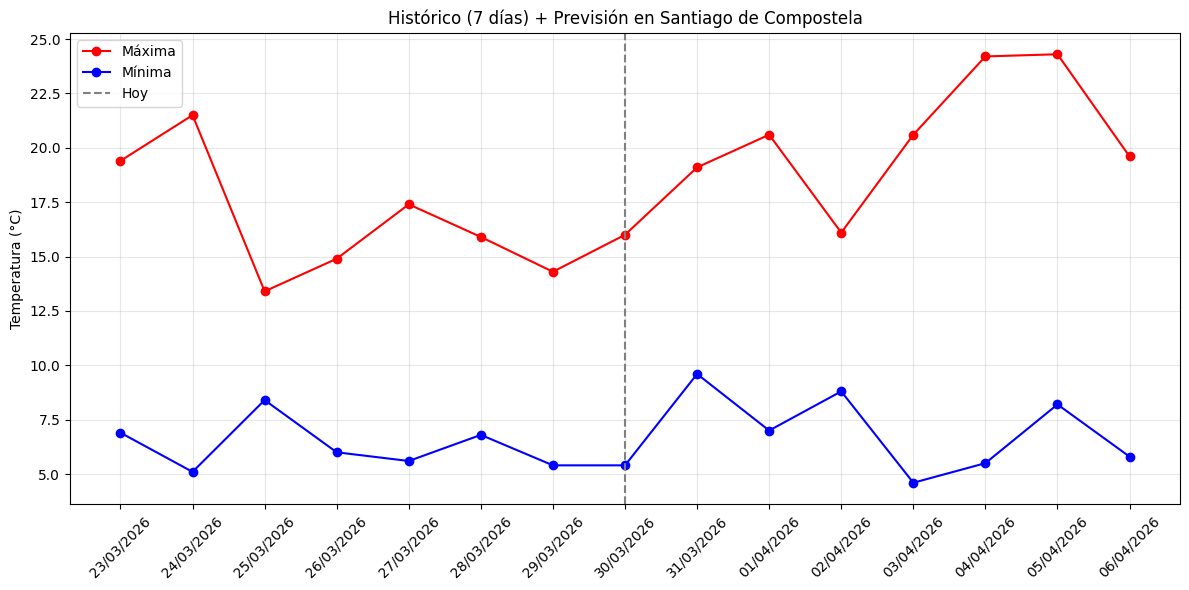

La gráfica muestra un rango temporal de 15 días. En ella se observa la transición entre los registros reales de la última semana y la tendencia prevista para los próximos días, utilizando una línea vertical para identificar el día actual.

### Pista

La API de Open-Meteo no permite realizar búsquedas por nombre de ciudad (como "Santiago" o "Madrid"). En su lugar, utiliza coordenadas geográficas:

- Localización: Obtén la latitud y longitud de tu lugar de residencia (puedes consultarlas fácilmente en Google Maps o servicios similares).

- La documentación de Open-Meteo cuenta con un generador dinámico de URLs. No es necesario leer toda la documentación técnica de forma extensiva; basta con seleccionar en los menús de su web los parámetros que necesitas (temperaturas diarias, rango de días pasados, zona horaria, etc.) y la propia página construirá el endpoint por ti.

### **Tu solución**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import requests

In [ ]:
response = requests.get('https://api.open-meteo.com/v1/forecast')

if response.status_code == 200:
  content = response.content
  print(content)
#hay que introducir parámetros si no no hay respuesta.

Solucion

In [ ]:
url = "https://api.open-meteo.com/v1/forecast" #definimos la pagina de open meteo
params = {"latitude": 39.5696,"longitude": 2.6502,"daily": "temperature_2m_max,temperature_2m_min","past_days": 7,"forecast_days": 8,"timezone": "auto"} #coordenadas de Mallorca
response =requests.get(url, params=params) #realizamos la peticion de los datos a partir de la URL y los parámetros,.
data =response.json() #guardamos el json en una variable.
print(data) #revisamos los datos
df =pd.DataFrame(data["daily"]) #convertimos a pandas
df.head(3) #revisamos con un head los datos.

In [ ]:
df["time"] = pd.to_datetime(df["time"])#Convertimos la columna "time" a formato fecha
fecha_hoy = df["time"].iloc[7] #Guardamos el día actual (posición 7 porque hay 7 días pasados)
df.set_index("time", inplace=True) #establecemos la columna time como indice del DF
df.index = df.index.strftime("%d/%m/%Y") #Establecemos la fecha al formato español dia/mes/año
#df.head(3)# Mostramos el resultado final

In [ ]:
#estilo visual + tamaño de la figura.
plt.style.use("ggplot")
plt.figure(figsize=(12,6))

#Ploteamos las temperaturas yu añadimos la linea vertical
plt.plot(df.index, df["temperature_2m_max"], label="Temperatura max", color="salmon", alpha=0.6, linewidth=3)
plt.plot(df.index, df["temperature_2m_min"], label="Temperatura min", color="skyblue", alpha=0.6, linewidth=3)
plt.axvline(x=df.index[7], linestyle='--', color="black", label="día actual")
#detalles bascos.
plt.title("Temperaturas en Madrid")
plt.xlabel("Fecha")
plt.ylabel("Temperatura")
plt.legend(loc="upper left") #añadimos el legend izquierda arriba
plt.grid(True)
plt.xticks(rotation=45) #inclinamos las flechas aunque ya se leian bien para darle un toque.
plt.show()

## **Apartado 2 - La evolución del Euro con Frankfurter API (2,5/25 ptos)**


Aunque el euro (€) no entró en circulación física hasta 2002, su existencia oficial en los mercados financieros comenzó el 1 de enero de 1999, momento en el que se fijaron sus tipos de cambio fijos y empezó a cotizar frente a otras divisas.

Para este ejercicio, utilizaremos la [Frankfurter API](https://frankfurter.dev/), una API de código abierto que ofrece datos de referencia publicados por el Banco Central Europeo (BCE).

Objetivo del ejercicio:
Tras consultar la documentación de la API, deberás representar gráficamente la evolución del tipo de cambio del euro frente a la libra esterlina (GBP) y el dólar estadounidense (USD), abarcando desde el inicio de sus registros históricos (1999) hasta la actualidad.

La gráfica resultante debe seguir un formato similar al siguiente:

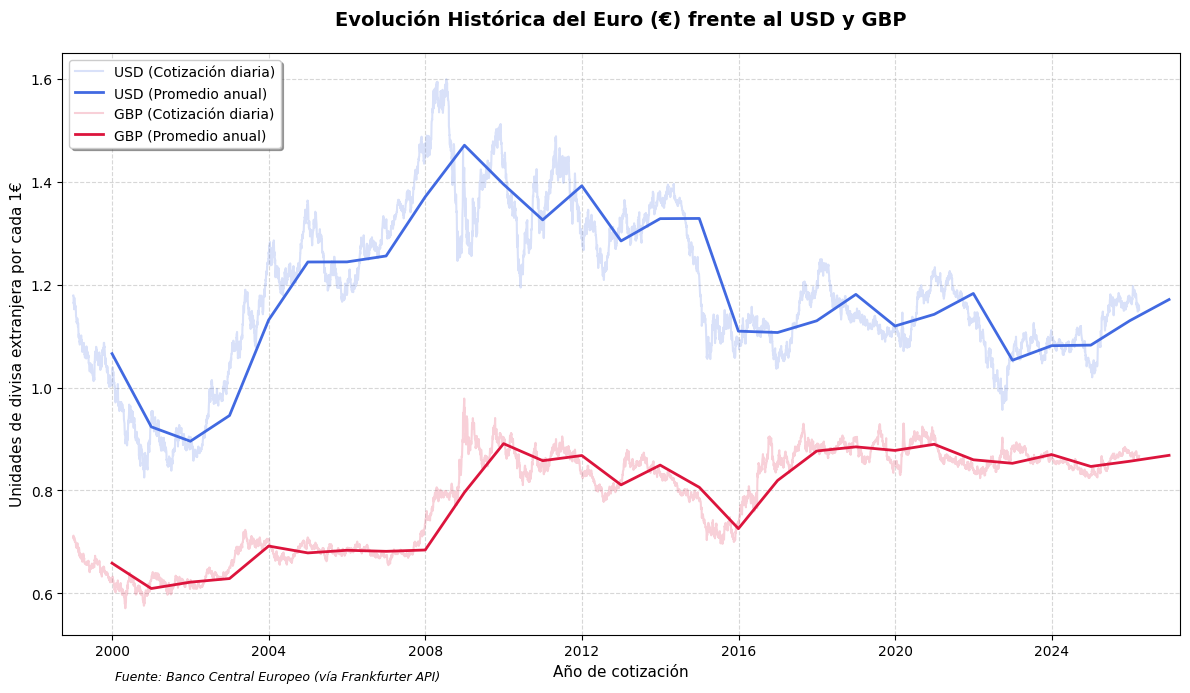

Fíjate que en la gráfica aparecen representadas **4 líneas**:

- Media anual de la conversión de Euro a Libra (£)
- Media anual de la conversión de Euro a Dólar (\$)
- Balance diario de la conversión de Euro a Libra (£)
- Balance diario de la conversión de Euro a Dólar (\$)

Para favorecer la manipulación de los datos, es recomendado utilizar Pandas para indexar la información rescatada de la API y conseguir un **dataframe con series temporales**. La **clave será que cada fecha que aparezca sea el índice de una fila de la tabla**.

Por ejemplo:

In [ ]:
import requests
import pandas as pd

url = "https://api.frankfurter.dev/v1/latest"
data = requests.get(url).json()

date = data['date']

rows = [data['rates']]
indexes = [date]

df = pd.DataFrame(rows)
df.index = indexes

df.index = pd.to_datetime(df.index)
df

Una vez que tengamos muchos valores indexados por fechas, podemos hacer una media anual en Pandas con el siguiente código:

```python
df.resample('YE').mean()
```

Representar un dataframe con índices temporales es sencillo. Puedes apoyarte del siguiente tutorial:

https://www.geeksforgeeks.org/python/pandas-plot-multiple-time-series-dataframe-into-a-single-plot/

### **Tu solución**

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# TODO:reune información y representa gráficamente la evolución del tipo de cambio
# del euro frente a la libra esterlina (GBP) y el dólar estadounidense (USD).

In [ ]:
url = "https://api.frankfurter.app/1999-01-01..2024-12-31?from=EUR&to=USD,GBP"
data = requests.get(url).json() #añadimos a la variable data el json
#print(data)
df =pd.DataFrame.from_dict(data["rates"], orient="index") #generamos el dataframe a partir de los datos temporales. DIccionario con clave fecha y valor el cambio.
df.index = pd.to_datetime(df.index) #convertimos el indice a formato datetime.
df = df.sort_index() #ordenamos los datos por fecha.
#calcular media anual
df_3 = df.resample("YE").mean() #realizamos la media anual.
plt.style.use("ggplot") #utilizamos el estilo de ggplot de R

#Ploteanmos las series temporale y las medias.
plt.figure(figsize=(14,8))
plt.plot(df.index, df["USD"], label="USD", color="skyblue",alpha=0.4,linewidth=3)
plt.plot(df.index, df["GBP"], label="GBP", color="salmon",alpha=0.4,linewidth=3)
plt.plot(df_3.index, df_3["USD"], label="USD media anual",color="skyblue",linewidth=3)
plt.plot(df_3.index, df_3["GBP"], label="GBP media anual",color="salmon",linewidth=3)

#Detalles básicos.
plt.title("Euro frente a USD y GBP")
plt.xlabel("Año")
plt.ylabel("Euro tipo de cambio")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

## **Apartado 3 - Análisis libre y exploración de datos con APIs (3,5/25 ptos)**


Este es un ejercicio abierto diseñado para que pongas en práctica tu capacidad de exploración autónoma. El objetivo es que selecciones una temática o fenómeno de tu interés (climático, económico o una combinación de ambos) y utilices las librerías vistas en los ejercicios anteriores para extraer, procesar y analizar la información. Tienes total libertad para elegir el tema, siempre que se fundamente en datos reales obtenidos mediante las 2 APIs usadas en los apartados anteriores ([Open-Meteo](https://open-meteo.com/en/docs) y [API Frankfurter](https://frankfurter.dev/)).

####Vías de investigación sugeridas:

Puedes optar por una de estas líneas o **proponer un enfoque propio**:

  **Opción A: Análisis Climático (Open-Meteo)**

Puedes utilizar tanto el servicio de previsión como la [**Historical Weather API**](https://open-meteo.com/en/docs/historical-weather-api?start_date=2010-01-01&end_date=2019-12-31) si deseas realizar comparativas con registros de décadas anteriores.

  - Análisis histórico: Comparar variables (temperatura, viento, radiación) entre diferentes épocas o años significativos de una región concreta.

  - Detección de anomalías: Identificar eventos climáticos extremos en un intervalo temporal de tu elección.

 **Opción B: Análisis Económico (API Frankfurter)**

  - Impacto de contextos globales: Estudiar la volatilidad o tendencia de una moneda frente al Euro en periodos de inestabilidad o grandes eventos geopolíticos.

  - Estudiar cómo afectó el Brexit a la Libra (GBP).

  - Evolución del poder adquisitivo: Analizar series temporales de cambio de moneda (ej. EUR/JPY, EUR/USD, EUR/GBP) para identificar ciclos de fortaleza o debilidad de una divisa.

###Requisitos del ejercicio:

- El código debe demostrar la construcción del endpoint (uso de parámetros como fechas, símbolos o filtros), la obtención de los datos y su posterior estructuración y limpieza mediante pandas.

- Visualización: Debes generar una representación gráfica que facilite la comprensión de la tendencia o fenómeno analizado.

- Informe de conclusiones: Elabora una breve interpretación de tus hallazgos con una **extensión máxima de 15 líneas**. El informe debe explicar qué fenómeno se estudió, qué se observó y qué conclusiones principales se extraen de la visualización.

###**Criterios de valoración**

Para la evaluación de este apartado se tendrá en cuenta:

- Autonomía y Exploración: la capacidad para investigar la documentación.

- Rigor y profundidad en el procesamiento de datos.

- Calidad de la comunicación visual: la claridad de la gráfica generada (etiquetado, escalas y diseño) para apoyar el análisis.

- Capacidad de síntesis: la precisión del informe final para resumir los hallazgos más relevantes en el espacio solicitado.

#Solucion

En este análisis vamos a graficar tres monedas distintas con equivalencias parecidas al euro (franco suizo, dolar y lina esterlina) frente al euro.
Añadiremos 3 momentos históricos de crisis financieras:


1.   Crisis 2008: Crisis inmobiliaria por las hipotecas surprime.
2.   Crisis 2012: Crisis que afecto a Europa sobre el exceso de deuda (sobretodo Grecia)
3.   Crisis Covid: Crisis por el virus del COVID-19

Revisaremos el comportamiento de las monedas en esos momentos históricos.

In [ ]:
url = "https://api.frankfurter.app/2004-01-01..2024-12-31?from=EUR&to=USD,GBP,CHF"
data = requests.get(url).json() #añadimos a la variable data el json
#print(data)
df =pd.DataFrame.from_dict(data["rates"], orient="index") #generamos el dataframe a partir de los datos temporales. DIccionario con clave fecha y valor el cambio.
df.index = pd.to_datetime(df.index) #convertimos el indice a formato datetime.
df = df.sort_index() #ordenamos los datos por fecha.

#Generamos la grafica y la media
plt.figure(figsize=(14,8))
plt.style.use("ggplot")
df_yearly = df.resample("Y").mean() #media anual

#Series diarias Y MEDIAS
plt.plot(df.index, df["USD"], label="USD", color="skyblue", alpha=0.5)
plt.plot(df.index, df["GBP"], label="GBP", color="salmon", alpha=0.5)
plt.plot(df.index, df["CHF"], label="CHF",color="green", alpha=0.5)

plt.plot(df_yearly.index, df_yearly["USD"], color="skyblue", linewidth=1.5)
plt.plot(df_yearly.index, df_yearly["GBP"], color="salmon", linewidth=1.5)
plt.plot(df_yearly.index, df_yearly["CHF"], color="green", linewidth=1.5)

#eventos a lo largo de los años
plt.axvline(pd.to_datetime("2008-09-15"), color="black", linestyle="--", label="Crisis 2008")
plt.axvline(pd.to_datetime("2012-07-01"), color="black", linestyle="--", label="Crisis 2012")
plt.axvline(pd.to_datetime("2020-03-01"), color="black", linestyle="--", label="COVID")

# Detalles
plt.title("Monedas frente al Euro en momentos históricos de crisis")
plt.xlabel("Fecha")
plt.ylabel("Tipo de cambio")
plt.legend()
plt.grid(True)
plt.show()

Antes que nada, podemos comprobar que las 3 divisas convergen hacia un rango próximo. Vemos que las medias anuales tienen temporalidades de crecimiento y decrecimiento.

Revisando el impacto de las diferentes del Euro frente a las 3 monedas:

*   Crisis 2008: Vemos gran volatilidad en todas las monedas. Sobretodo en EURO/DOLAR
*   Crisis 2012: Vemos gran volatilidad EURO/DOLAR y Euro/gbp.
*   Crisis Covid: Vemos una ligera volatilidad en todas pero permanecen más estables.

Podemos concluir que las crisis económicas afectan en gran medida al cambio de divisas. La crisis COVID, a pesar que tuvo un gran impacto económico, no tuvo tanta volatilidad como la crisis de 2008.



#INFORME DE USO DE IA


*   Apoyo en la resolución de dudas, interpretación y entendimiento de los problemas. Sobretodo a la hora de consultar información o material docente/didactico
*   Reconocimiento de errores al ejecutar código.
*   Dónde más valor tiene es en el entendimiento y aprendizaje de conceptos sin lugar a dudas.



Ejemplo de prompt:
¿Puedo decir que en la crisis de 2008 el Euro perdió valor frente al dolar ya que el **EUR/USD** cae? La IA consolida una respuesta de la razón porque no puedo decirlo concluyendo que solo podemos concluir que afectó en la volatilidad de las divisas sin especificar si fue el euro que cayó frente al dolar o viceversa. ¿Podríamos hacer inferencia en el resto de monedas graficadas para saberlo? No se puede determinar solo con esos datos.